# Conn2Conn — W&B Results Scraper

Pulls best-trial runs from W&B, builds status/metric tables, and integrates with local `ray_results` artifacts.

**Sections**
1. Setup
2. Define experiment spec
3. Fetch W&B records
4. Debug: status table (which seeds completed / failed)
5. Metrics table (test demeaned Pearson, mean ± std across seeds)
6. Raw per-seed DataFrame
7. Local artifact enrichment (identifiability, PCA structure)
8. Plots

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path('/scratch/asr655/neuroinformatics/Conn2Conn')
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import wandb

from results.results_scraper import (
    build_experiment_records,
    records_to_df,
    build_status_table,
    build_metric_table,
    enrich_records_with_local,
    load_local_artifact_df,
)
import importlib
importlib.reload(sys.modules['results.results_scraper'])

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Log into W&B (reads from ~/.netrc automatically).
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/asr655/.netrc.
wandb: Currently logged in as: asratzan (alexander-ratzan-new-york-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Experiment Spec
Edit this cell to change which models / sources / seeds to pull.

In [2]:
# ── SC vs SC_r2t vs SC+SC_r2t experiment ──────────────────────────────────

# Models that support all three source conditions.
MULTIMODAL_MODELS = [
    'CrossModal_PCA_PLS',
    'CrossModal_PCA_PLS_learnable',
]

# Single-source models (SC and SC_r2t only — no SC+SC_r2t).
SINGLE_SOURCE_MODELS = [
    'CrossModalPCA',
    'CrossModal_PLS_SVD',
]

SOURCES_MULTI  = ['SC', 'SC_r2t', 'SC+SC_r2t']
SOURCES_SINGLE = ['SC', 'SC_r2t']
SEEDS = [0, 1, 2, 3, 4]

# Primary metric for ranking / table display.
PRIMARY_METRIC = 'demeaned_pearson'   # key in RunRecord.test_metrics
SECONDARY_METRIC = 'mse'

## 2. Fetch W&B Records

`build_experiment_records` issues one W&B API call per model to fetch all
`best_trial_report` runs, then cross-joins against the expected
(model × source × seed) matrix.  Set `count_trials=False` to skip the
per-sweep trial-count calls if you only care about metrics.

In [3]:
records_multi = build_experiment_records(
    models=MULTIMODAL_MODELS,
    sources=SOURCES_MULTI,
    seeds=SEEDS,
    count_trials=True,
    verbose=True,
)

records_single = build_experiment_records(
    models=SINGLE_SOURCE_MODELS,
    sources=SOURCES_SINGLE,
    seeds=SEEDS,
    count_trials=True,
    verbose=True,
)

all_records = records_multi + records_single
n_complete = sum(r.status == 'complete' for r in all_records)
n_missing  = sum(r.status == 'missing'  for r in all_records)
print(f"\nTotal: {len(all_records)}  complete={n_complete}  missing={n_missing}")

Fetching W&B runs for CrossModal_PCA_PLS…
  ⚠ run 37043_best (rpwcq05u): could not parse source='unknown' seed=-1 — skipping
  ⚠ run 473a4_best (bqobszm1): could not parse source='unknown' seed=-1 — skipping
  ⚠ run 506d6_best (ld38xmrz): could not parse source='unknown' seed=-1 — skipping
  ✓ CrossModal_PCA_PLS | src=SC+SC_r2t | seed=4 → 16 tune trials  (run: cc410_best)
  ✓ CrossModal_PCA_PLS | src=SC | seed=4 → 16 tune trials  (run: 8ada3_best)
  ✓ CrossModal_PCA_PLS | src=SC_r2t | seed=4 → 16 tune trials  (run: 9a167_best)
  ✓ CrossModal_PCA_PLS | src=SC | seed=3 → 16 tune trials  (run: ce59b_best)
  ✓ CrossModal_PCA_PLS | src=SC_r2t | seed=3 → 16 tune trials  (run: 21aa8_best)
  ✓ CrossModal_PCA_PLS | src=SC+SC_r2t | seed=3 → 16 tune trials  (run: 206fa_best)
  ✓ CrossModal_PCA_PLS | src=SC_r2t | seed=2 → 16 tune trials  (run: eb184_best)
  ✓ CrossModal_PCA_PLS | src=SC | seed=2 → 16 tune trials  (run: d157d_best)
  ✓ CrossModal_PCA_PLS | src=SC_r2t | seed=1 → 16 tune trials  (run

In [4]:
## Diagnostic: inspect raw W&B config + summary for one best-trial run
#
# What to look for:
#   • "source" and "shuffle_seed" in config keys → run was produced with the
#     fixed main.py (post-fix); scraper resolves source/seed from W&B directly.
#   • Keys absent → pre-fix run; scraper falls back to local checkpoint config.json
#     at ray_checkpoints/{model}_tune_{ray_tune_id}/{ray_trial_id}/final/config.json.
#   • Summary should always have val_demeaned_r and eval_test/* metrics.

from results.results_scraper import (
    fetch_best_trial_runs, _source_from_config, _seed_from_config,
    _source_seed_from_local_checkpoint,
)

_diag_model = (MULTIMODAL_MODELS + SINGLE_SOURCE_MODELS)[0]
_raw_runs = fetch_best_trial_runs(_diag_model)
print(f"Found {len(_raw_runs)} best-trial run(s) for '{_diag_model}'")

if _raw_runs:
    r0 = _raw_runs[0]
    _cfg = dict(r0.config)
    print(f"\nRun : {r0.name}")
    print(f"Group: {r0.group}")
    print(f"Tags : {r0.tags}")
    print(f"\nConfig keys: {list(_cfg.keys())}")
    for k in ('source', 'shuffle_seed', 'target', 'data', 'data.source', 'data.shuffle_seed'):
        if k in _cfg:
            print(f"  [{k}] = {_cfg[k]}")

    _src  = _source_from_config(_cfg)
    _seed = _seed_from_config(_cfg)
    print(f"\nFrom W&B config  → source='{_src}'  seed={_seed}")

    if _src == 'unknown' or _seed == -1:
        _ray_tune_id  = _cfg.get('ray_tune_id')
        _ray_trial_id = _cfg.get('ray_trial_id')
        _fb_src, _fb_seed = _source_seed_from_local_checkpoint(
            _ray_tune_id, _ray_trial_id, _diag_model
        )
        print(f"Local checkpoint fallback → source='{_fb_src}'  seed={_fb_seed}")
        if _fb_src == 'unknown':
            print("  (pre-fix run AND no local checkpoint found — "
                  "re-run experiment with updated main.py to populate W&B metadata)")

    print(f"\nSummary metrics:")
    _s = dict(r0.summary)
    for k in sorted(_s):
        if any(k.startswith(p) for p in ('val_', 'train_', 'eval_test/')):
            print(f"  {k}: {_s[k]}")

Found 27 best-trial run(s) for 'CrossModal_PCA_PLS'

Run : cc410_best
Group: CrossModal_PCA_PLS_tune_cc410
Tags : ['CrossModal_PCA_PLS', 'best_trial_report', 'prod', 'ray_tune_id:1773445134', 'source_trial:cc410_00011']

Config keys: ['data', 'model', 'ray_tune_id', 'ray_trial_id']
  [data] = {'hemi': 'both', 'source': 'SC+SC_r2t', 'target': 'FC', 'parcellation': 'Glasser', 'shuffle_seed': 4}

From W&B config  → source='SC+SC_r2t'  seed=4

Summary metrics:
  eval_test/avg_rank: 0.7245496383957922
  eval_test/demeaned_pearson: 0.09175418726248086
  eval_test/mse: 0.013708083890378475
  eval_test/pearson: 0.8391628265380859
  eval_test/r2: -0.005240228027105331
  eval_test/top1_acc: 0.02564102564102564
  train_demeaned_r: 0.17269857044860132
  train_mse: 0.013161740265786648
  train_pearson_r: 0.8400803804397583
  val_demeaned_r: 0.10272088845894774
  val_mse: 0.014018041081726553
  val_pearson_r: 0.8347586989402771


## 3. Debug — Status Table

Shows which (model × source × seed) cells completed and how many tune
trials were explored. **Cells marked `✗ MISSING` indicate failed or
never-run experiments.**

In [5]:
status_multi  = build_status_table(records_multi)
status_single = build_status_table(records_single)

print('── Multimodal models ──')
display(status_multi)

print('\n── Single-source models ──')
display(status_single)

── Multimodal models ──


source                          SC                         SC+SC_r2t        \
seed                             0     1     2     3     4         0     1   
model                                                                        
CrossModal_PCA_PLS            ✓ 16  ✓ 16  ✓ 16  ✓ 16  ✓ 16      ✓ 16  ✓ 16   
CrossModal_PCA_PLS_learnable  ✓ 30  ✓ 30  ✓ 30  ✓ 30  ✓ 30      ✓ 30  ✓ 30   

source                                         SC_r2t                          
seed                             2     3     4      0     1     2     3     4  
model                                                                          
CrossModal_PCA_PLS            ✓ 16  ✓ 16  ✓ 16   ✓ 16  ✓ 16  ✓ 16  ✓ 16  ✓ 16  
CrossModal_PCA_PLS_learnable  ✓ 30  ✓ 30  ✓ 30   ✓ 30  ✓ 30  ✓ 30  ✓ 30  ✓ 30


── Single-source models ──


source                SC                         SC_r2t                    \
seed                   0     1     2     3     4      0     1     2     3   
model                                                                       
CrossModalPCA        ✓ 6   ✓ 6   ✓ 6   ✓ 6   ✓ 6    ✓ 6   ✓ 6   ✓ 6   ✓ 6   
CrossModal_PLS_SVD  ✓ 12  ✓ 12  ✓ 12  ✓ 12  ✓ 12   ✓ 12  ✓ 12  ✓ 12  ✓ 12   

source                    
seed                   4  
model                     
CrossModalPCA        ✓ 6  
CrossModal_PLS_SVD  ✓ 12

## 4. Raw Per-Seed DataFrame

Flat table with one row per (model, source, seed).  Useful for per-seed
inspection and feeding into downstream plotting.

In [13]:
df = records_to_df(all_records)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}\n')

# Metric columns only exist when at least one run is complete.
base_cols   = ['model', 'source', 'seed', 'status', 'n_tune_trials', 'wandb_run_name']
metric_cols = [c for c in ['test_demeaned_pearson', 'test_mse', 'val_demeaned_r'] if c in df.columns]
display(df[base_cols + metric_cols].sort_values(['model', 'source', 'seed']))

Shape: (50, 23)
Columns: ['model', 'source', 'seed', 'status', 'n_tune_trials', 'wandb_run_id', 'wandb_run_name', 'wandb_group', 'ray_tune_id', 'ray_trial_id', 'local_artifact', 'val_demeaned_r', 'val_mse', 'val_pearson_r', 'train_demeaned_r', 'train_mse', 'train_pearson_r', 'test_avg_rank', 'test_demeaned_pearson', 'test_mse', 'test_pearson', 'test_r2', 'test_top1_acc']



,model,source,seed,status,n_tune_trials,wandb_run_name,test_demeaned_pearson,test_mse,val_demeaned_r
30,CrossModalPCA,SC,0,complete,6,c4b1e_best,0.0158,0.0142,0.0247
31,CrossModalPCA,SC,1,complete,6,ceef5_best,0.0278,0.0145,-0.0029
32,CrossModalPCA,SC,2,complete,6,f60bf_best,0.0037,0.0147,0.0212
33,CrossModalPCA,SC,3,complete,6,382d2_best,0.0029,0.0142,0.0321
34,CrossModalPCA,SC,4,complete,6,8483d_best,0.0046,0.0145,0.0233
35,CrossModalPCA,SC_r2t,0,complete,6,bccf9_best,-0.0082,0.0235,-0.0235
36,CrossModalPCA,SC_r2t,1,complete,6,dbdaa_best,0.0105,0.0160,0.0243
37,CrossModalPCA,SC_r2t,2,complete,6,35183_best,-0.0085,0.0203,-0.0075
38,CrossModalPCA,SC_r2t,3,complete,6,6e628_best,-0.0020,0.0169,0.0063
39,CrossModalPCA,SC_r2t,4,complete,6,d48c9_best,-0.0064,0.0161,-0.0052


## 5. Metrics Table — Test Demeaned Pearson

Aggregated across seeds (mean ± std).  Only seeds with `status='complete'`
contribute.  Missing cells show `NaN`.

In [11]:
# Show tables for all core metrics of interest, with columns ordered: SC, SC_r2t, SC+SC_r2t

# Metric names per W&B summary (from image): these are test metrics, so "eval_test/..." → "pearson", "mse", etc.
metrics_of_interest = [
    "demeaned_pearson",      
    "pearson",
    "mse",      
    "avg_rank",
    "top1_acc",
]

# Mapping to the column order desired (for sources)
source_order = ["SC", "SC_r2t", "SC+SC_r2t"]

def reorder_columns(df, order):
    # Only keep columns present, in order requested
    cols = [c for c in order if c in df.columns]
    return df[cols] if cols else df

for metric in metrics_of_interest:
    # metric argument expects the metric key (e.g., "demeaned_pearson", "mse", "pearson", etc.)
    table_multi  = build_metric_table(records_multi,  metric=metric, agg='mean±std')
    table_single = build_metric_table(records_single, metric=metric, agg='mean±std')
    metric_table = pd.concat([table_multi, table_single]).sort_index()
    # Reorder columns for the three sources: SC, SC_r2t, SC+SC_r2t
    metric_table = reorder_columns(metric_table, source_order)
    print(f"Test {metric} — mean ± std across seeds")
    display(metric_table)

Test demeaned_pearson — mean ± std across seeds


source,SC,SC_r2t,SC+SC_r2t
model,,,
CrossModalPCA,0.0110 ± 0.0096 (n=5),-0.0029 ± 0.0071 (n=5),NaN
CrossModal_PCA_PLS,0.0843 ± 0.0067 (n=5),0.0464 ± 0.0082 (n=5),0.0784 ± 0.0078 (n=5)
CrossModal_PCA_PLS_learnable,0.0988 ± 0.0103 (n=5),0.0217 ± 0.0149 (n=5),0.0826 ± 0.0060 (n=5)
CrossModal_PLS_SVD,0.0659 ± 0.0159 (n=5),0.0437 ± 0.0079 (n=5),NaN


Test pearson — mean ± std across seeds


source,SC,SC_r2t,SC+SC_r2t
model,,,
CrossModalPCA,0.8251 ± 0.0027 (n=5),0.7787 ± 0.0311 (n=5),NaN
CrossModal_PCA_PLS,0.8334 ± 0.0072 (n=5),0.8338 ± 0.0049 (n=5),0.8348 ± 0.0044 (n=5)
CrossModal_PCA_PLS_learnable,0.8363 ± 0.0034 (n=5),0.8332 ± 0.0054 (n=5),0.8360 ± 0.0034 (n=5)
CrossModal_PLS_SVD,0.8263 ± 0.0111 (n=5),0.8246 ± 0.0106 (n=5),NaN


Test mse — mean ± std across seeds


source,SC,SC_r2t,SC+SC_r2t
model,,,
CrossModalPCA,0.0144 ± 0.0002 (n=5),0.0186 ± 0.0029 (n=5),NaN
CrossModal_PCA_PLS,0.0138 ± 0.0004 (n=5),0.0137 ± 0.0003 (n=5),0.0137 ± 0.0002 (n=5)
CrossModal_PCA_PLS_learnable,0.0135 ± 0.0002 (n=5),0.0138 ± 0.0003 (n=5),0.0136 ± 0.0002 (n=5)
CrossModal_PLS_SVD,0.0144 ± 0.0009 (n=5),0.0145 ± 0.0008 (n=5),NaN


Test avg_rank — mean ± std across seeds


source,SC,SC_r2t,SC+SC_r2t
model,,,
CrossModalPCA,0.5158 ± 0.0175 (n=5),0.4971 ± 0.0175 (n=5),NaN
CrossModal_PCA_PLS,0.6954 ± 0.0170 (n=5),0.6108 ± 0.0232 (n=5),0.6788 ± 0.0252 (n=5)
CrossModal_PCA_PLS_learnable,0.7413 ± 0.0482 (n=5),0.5503 ± 0.0260 (n=5),0.6604 ± 0.0220 (n=5)
CrossModal_PLS_SVD,0.6317 ± 0.0394 (n=5),0.5873 ± 0.0220 (n=5),NaN


Test top1_acc — mean ± std across seeds


source,SC,SC_r2t,SC+SC_r2t
model,,,
CrossModalPCA,0.0123 ± 0.0083 (n=5),0.0041 ± 0.0038 (n=5),NaN
CrossModal_PCA_PLS,0.0349 ± 0.0170 (n=5),0.0174 ± 0.0077 (n=5),0.0277 ± 0.0124 (n=5)
CrossModal_PCA_PLS_learnable,0.0462 ± 0.0149 (n=5),0.0133 ± 0.0041 (n=5),0.0215 ± 0.0099 (n=5)
CrossModal_PLS_SVD,0.0297 ± 0.0127 (n=5),0.0236 ± 0.0095 (n=5),NaN


In [12]:
# Inspect failed / missing seeds in detail.
missing_df = df[df['status'] == 'missing']
if missing_df.empty:
    print('All expected runs completed.')
else:
    print(f'{len(missing_df)} missing runs:')
    display(missing_df[['model', 'source', 'seed']])

All expected runs completed.


In [ ]:
# Stratify PCA_PLS_CovProjector results by projector covariate input type
# (fs_all / fs_volumes / demo / fs_all_demo), then show mean ± std across seeds.

metrics_of_interest = [
    "demeaned_pearson",
    "pearson",
    "mse",
    "avg_rank",
    "top1_acc",
]

cov_type_order = ["fs_all", "fs_volumes", "demo", "fs_all_demo"]

def reorder_columns(df, order):
    cols = [c for c in order if c in df.columns]
    return df[cols] if cols else df

def _as_list(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    return [x]

def cov_type_from_record(r):
    cfg = r.config or {}
    model_cfg = cfg.get("model", {}) if isinstance(cfg.get("model", {}), dict) else {}
    cov_sources = model_cfg.get("cov_sources", cfg.get("model.cov_sources", []))
    cov_sources = sorted(_as_list(cov_sources))

    key = tuple(cov_sources)
    mapping = {
        ("fs_all",): "fs_all",
        ("fs_volumes",): "fs_volumes",
        ("age", "race_eth", "sex"): "demo",
        ("age", "fs_all", "race_eth", "sex"): "fs_all_demo",
    }
    return mapping.get(key, "unknown")

def build_metric_table_by_cov_type(records, metric, agg="mean±std", model_name="CrossModal_PCA_PLS_CovProjector"):
    rows = []
    for r in records:
        if r.status != "complete":
            continue
        if model_name is not None and r.model_name != model_name:
            continue
        val = r.test_metrics.get(metric)
        if val is None:
            continue
        rows.append({
            "model": r.model_name,
            "cov_type": cov_type_from_record(r),
            "value": float(val),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    if agg == "mean±std":
        def _fmt(vals):
            m, s = np.mean(vals), np.std(vals)
            return f"{m:.4f} ± {s:.4f}  (n={len(vals)})"
        out = df.groupby(["model", "cov_type"])["value"].apply(_fmt).unstack("cov_type")
    else:
        out = df.groupby(["model", "cov_type"])["value"].agg(agg).unstack("cov_type")

    return reorder_columns(out, cov_type_order)

# Use whichever record list contains your CovProjector runs (e.g., records_cov or records_single)
records_cov = records_single  # <- change if needed

for metric in metrics_of_interest:
    metric_table = build_metric_table_by_cov_type(records_cov, metric=metric, agg="mean±std")
    print(f"Test {metric} by projector covariate input — mean ± std across seeds")
    display(metric_table)


Test demeaned_pearson by projector covariate input — mean ± std across seeds


""


Test pearson by projector covariate input — mean ± std across seeds


""


Test mse by projector covariate input — mean ± std across seeds


""


Test avg_rank by projector covariate input — mean ± std across seeds


""


Test top1_acc by projector covariate input — mean ± std across seeds


""


## Plots

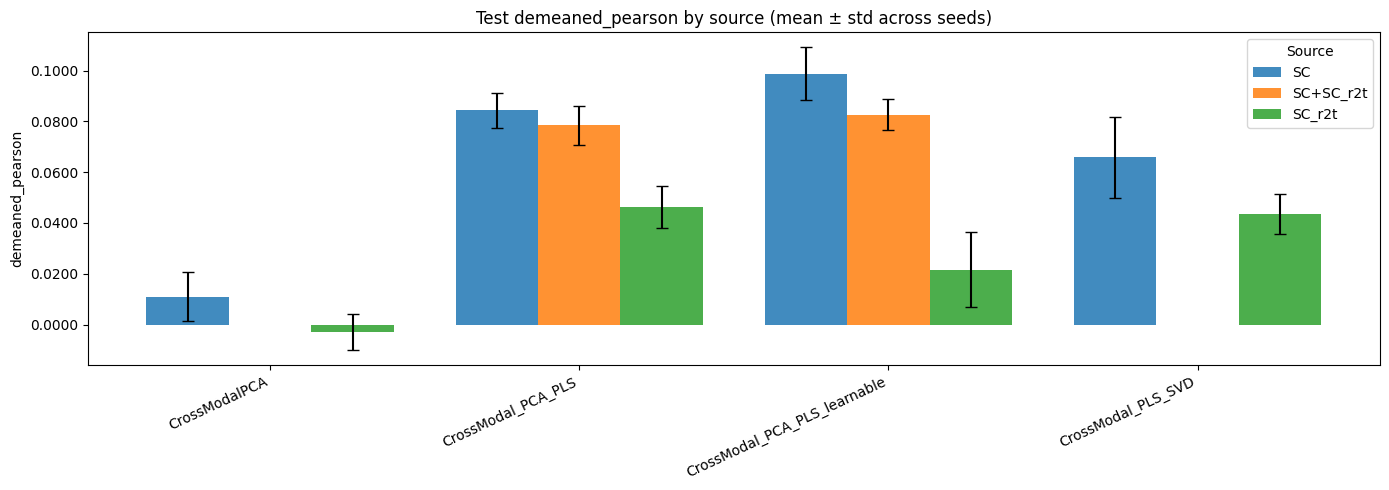

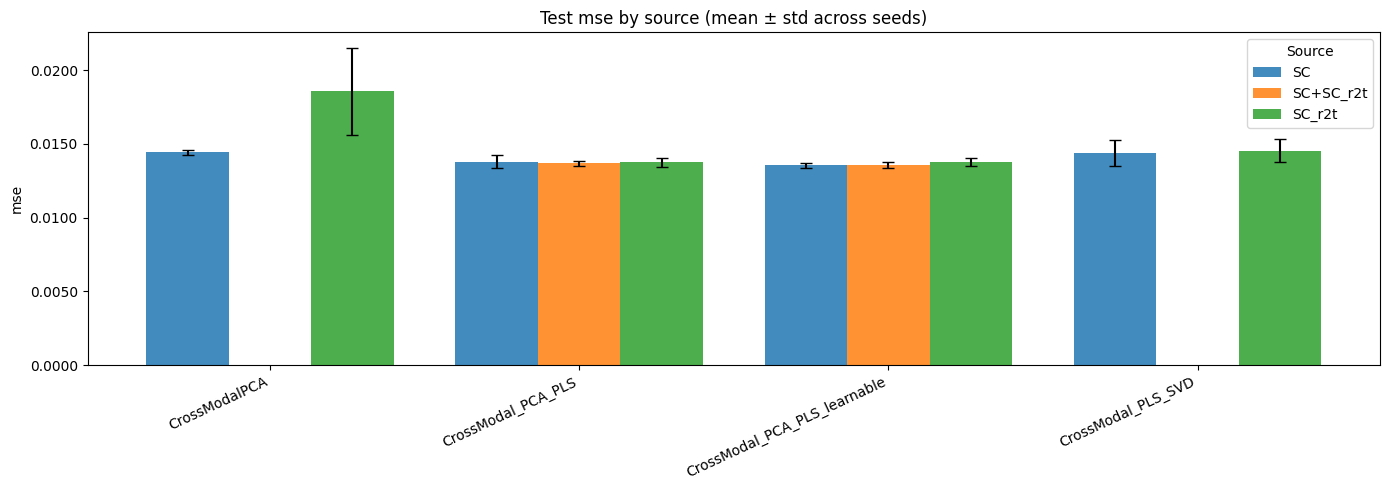

/tmp/ipykernel_28669/1669025184.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


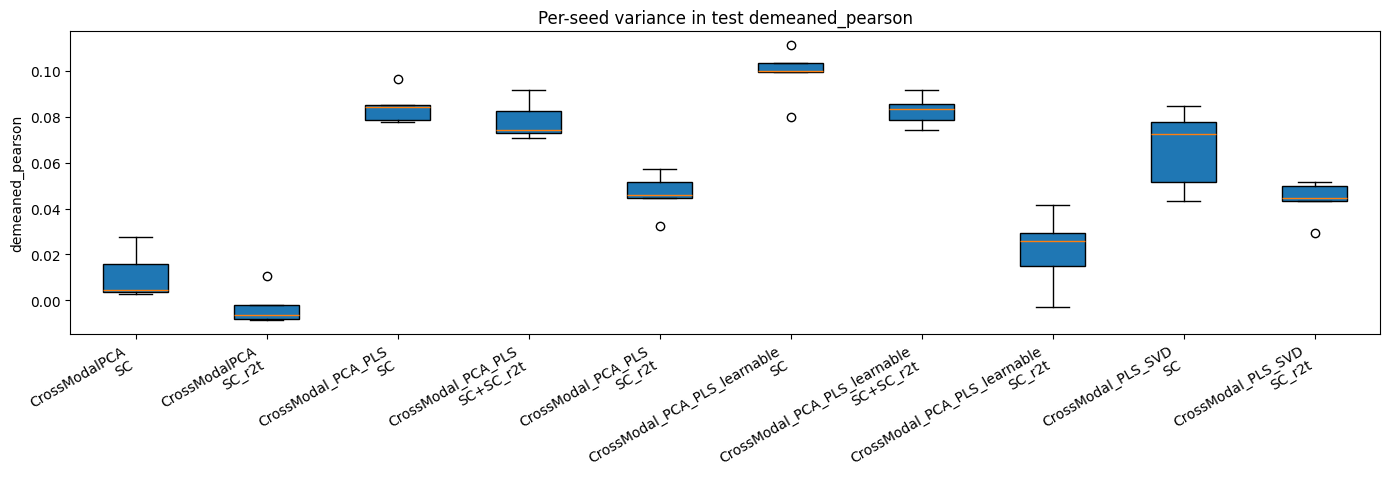

/tmp/ipykernel_28669/1669025184.py:85: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, patch_artist=True)


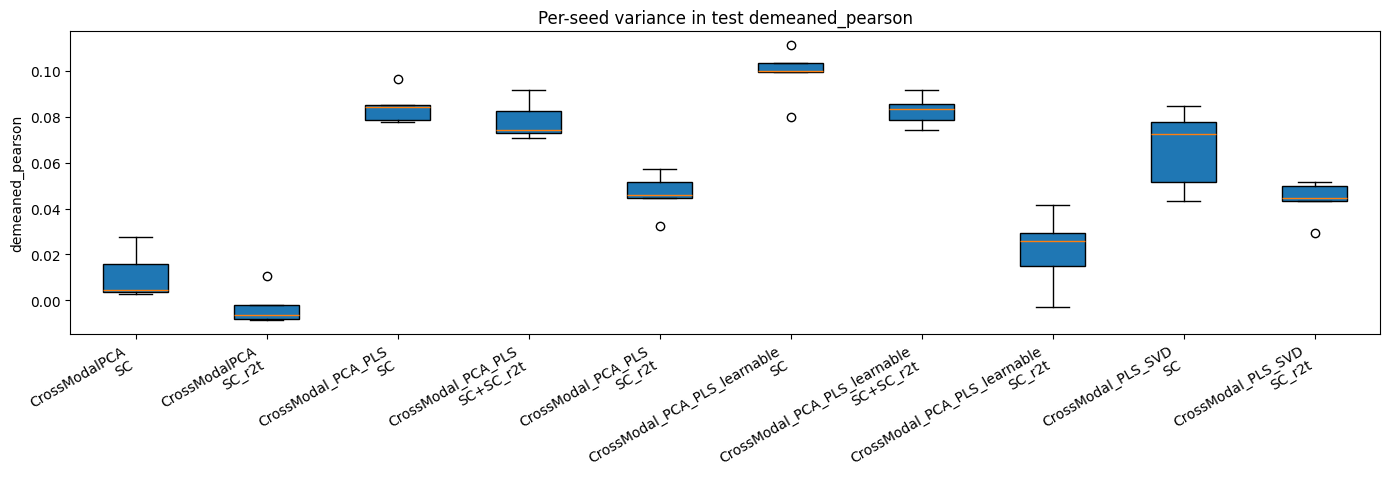

NameError: name 'local_df' is not defined

In [14]:
def plot_metric_by_source(
    records,
    metric='demeaned_pearson',
    title=None,
    figsize=(14, 5),
):
    """
    Grouped bar chart: one group per model, bars per source.
    Each bar shows mean across seeds; error bar shows ±1 std.
    Missing cells are skipped.
    """
    complete = [r for r in records if r.status == 'complete']
    if not complete:
        print('No complete records to plot.')
        return

    models  = sorted({r.model_name for r in complete})
    sources = sorted({r.source     for r in complete})

    x = np.arange(len(models))
    width = 0.8 / len(sources)
    offsets = np.linspace(-0.4 + width/2, 0.4 - width/2, len(sources))

    fig, ax = plt.subplots(figsize=figsize)
    for i, src in enumerate(sources):
        means, stds = [], []
        for mdl in models:
            vals = [
                r.test_metrics.get(metric)
                for r in complete
                if r.model_name == mdl and r.source == src
                and r.test_metrics.get(metric) is not None
            ]
            means.append(np.mean(vals) if vals else np.nan)
            stds.append(np.std(vals)  if vals else 0.0)
        ax.bar(x + offsets[i], means, width, yerr=stds,
               label=src, capsize=4, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha='right')
    ax.set_ylabel(metric)
    ax.set_title(title or f'Test {metric} by source (mean ± std across seeds)')
    ax.legend(title='Source')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    plt.tight_layout()
    plt.show()


plot_metric_by_source(all_records, metric=PRIMARY_METRIC)
plot_metric_by_source(all_records, metric=SECONDARY_METRIC)





def plot_seed_variance(
    records,
    metric='demeaned_pearson',
    source_filter=None,
    figsize=(14, 5),
):
    """
    Box plot: one box per (model, source) showing per-seed variance.
    """
    complete = [
        r for r in records
        if r.status == 'complete'
        and (source_filter is None or r.source in source_filter)
        and r.test_metrics.get(metric) is not None
    ]
    if not complete:
        print('No complete records to plot.')
        return

    from collections import defaultdict
    groups = defaultdict(list)
    for r in complete:
        key = f"{r.model_name}\n{r.source}"
        groups[key].append(r.test_metrics[metric])

    labels = sorted(groups.keys())
    data   = [groups[k] for k in labels]

    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(data, labels=labels, patch_artist=True)
    ax.set_ylabel(metric)
    ax.set_title(f'Per-seed variance in test {metric}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


plot_seed_variance(all_records, metric=PRIMARY_METRIC)
plot_seed_variance(all_records, metric=PRIMARY_METRIC, source_filter=['SC', 'SC_r2t', 'SC+SC_r2t'])







# ── Identifiability metrics (requires local artifact enrichment) ──────────
if not local_df.empty and 'test_heatmaps_demeaned_top1_acc' in local_df.columns:
    plot_df = local_df.copy()
    plot_df['label'] = plot_df['model'] + ' | ' + plot_df['source']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, ylabel in zip(
        axes,
        ['test_heatmaps_demeaned_top1_acc', 'test_heatmaps_demeaned_avg_rank_percentile'],
        ['Demeaned Top-1 Acc', 'Demeaned Avg Rank %ile'],
    ):
        if col not in plot_df.columns:
            continue
        grp = plot_df.groupby(['model', 'source'])[col]
        means = grp.mean().reset_index()
        means['label'] = means['model'] + '\n' + means['source']
        means = means.sort_values(col, ascending=False)
        ax.bar(means['label'], means[col], alpha=0.85)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print('Local artifact enrichment not available — skipping identifiability plots.')

## Local Artifact Enrichment

Merges full local `metrics_final.json` (identifiability heatmaps, violin,
PCA structure, Hungarian matching) into each RunRecord's `test_metrics`.
Only runs with a `local_artifact_path` are enriched; others are unchanged.

In [ ]:
all_records_enriched = enrich_records_with_local(all_records)

n_enriched = sum(
    1 for r in all_records_enriched
    if r.status == 'complete' and r.local_artifact_path
)
print(f'Enriched {n_enriched} / {sum(r.status=="complete" for r in all_records_enriched)} complete runs with local metrics.')

# Full local artifact DataFrame (mirrors local_results_utils.load_local_results).
local_df = load_local_artifact_df(all_records_enriched)
print(f'Local artifact DataFrame: {local_df.shape}')
if not local_df.empty:
    display(local_df[['model', 'source', 'seed',
                       'test_base_metrics_demeaned_pearson',
                       'test_heatmaps_demeaned_top1_acc',
                       'test_heatmaps_demeaned_avg_rank_percentile']].sort_values(
        ['model', 'source', 'seed']))

Enriched 35 / 35 complete runs with local metrics.
